### Pivot Table
> The pivot table takes simple column wise data as input , and groups the entries into two domensional table that provides a multidimentional summarization of th data

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

> tips is a restaurent data . it is a toy dataset.

In [5]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [16]:
## on the basis of gender average total bill
df.groupby('sex',observed=False)[['total_bill']].mean()

,total_bill
sex,
Male,20.744076
Female,18.056897


In [20]:
df.groupby(['sex','smoker'],observed=False)[['total_bill']].mean().unstack()

total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [32]:
df.pivot_table(index='sex',columns='smoker',values='total_bill',observed=False,aggfunc='sum')

smoker,Yes,No
sex,,
Male,1337.07,1919.75
Female,593.27,977.68


In [40]:
df.pivot_table(index='sex',columns='smoker',values=['total_bill','tip','size'],observed=False)

size                 tip           total_bill           
smoker       Yes        No       Yes        No        Yes         No
sex                                                                 
Male    2.500000  2.711340  3.051167  3.113402  22.284500  19.791237
Female  2.242424  2.592593  2.931515  2.773519  17.977879  18.105185

In [44]:
df.pivot_table(index=['sex','smoker'],columns=['day','time'],values='total_bill',observed=False)

day                 Thur               Fri                Sat        Sun
time               Lunch Dinner      Lunch  Dinner     Dinner     Dinner
sex    smoker                                                           
Male   Yes     19.171000    NaN  11.386667  25.892  21.837778  26.141333
       No      18.486500    NaN        NaN  17.475  19.929063  20.403256
Female Yes     19.218571    NaN  13.260000  12.200  20.266667  16.540000
       No      15.899167  18.78  15.980000  22.750  19.003846  20.824286

In [46]:
df.pivot_table(index=['sex','smoker'],columns=['day','time'],values=['total_bill','tip','size'],observed=False)

size                                                   tip  \
day                Thur              Fri              Sat       Sun      Thur   
time              Lunch Dinner     Lunch Dinner    Dinner    Dinner     Lunch   
sex    smoker                                                                   
Male   Yes     2.300000    NaN  1.666667    2.4  2.629630  2.600000  3.058000   
       No      2.500000    NaN       NaN    2.0  2.656250  2.883721  2.941500   
Female Yes     2.428571    NaN  2.000000    2.0  2.200000  2.500000  2.990000   
       No      2.500000    2.0  3.000000    2.0  2.307692  3.071429  2.437083   

                                                      total_bill         \
day                    Fri              Sat       Sun       Thur          
time          Dinner Lunch Dinner    Dinner    Dinner      Lunch Dinner   
sex    smoker                                                             
Male   Yes       NaN  1.90  3.246  2.879259  3.521333  19.171000    NaN   
       No        NaN   NaN  2.500  3.256563  3.115349  18.486500    NaN   
Female Yes       NaN  2.66  2.700  2.868667  3.500000  19.218571    NaN   
       No        3.0  3.00  3.250  2.724615  3.329286  15.899167  18.78   

                                                        
day                  Fri                Sat        Sun  
time               Lunch  Dinner     Dinner     Dinner  
sex    smoker                                           
Male   Yes     11.386667  25.892  21.837778  26.141333  
       No            NaN  17.475  19.929063  20.403256  
Female Yes     13.260000  12.200  20.266667  16.540000  
       No      15.980000  22.750  19.003846  20.824286

In [48]:
df.pivot_table(index=['sex','smoker'],columns=['day','time'],values=['total_bill','tip','size'],observed=False,aggfunc={'total_bill':'sum','tip':'max','size':'min'})

size                                     tip               \
day            Thur          Fri           Sat    Sun  Thur          Fri   
time          Lunch Dinner Lunch Dinner Dinner Dinner Lunch Dinner Lunch   
sex    smoker                                                              
Male   Yes      2.0    NaN   1.0    2.0    2.0    2.0  5.00    NaN  2.20   
       No       2.0    NaN   NaN    2.0    2.0    2.0  6.70    NaN   NaN   
Female Yes      2.0    NaN   2.0    2.0    1.0    2.0  5.00    NaN  3.48   
       No       1.0    2.0   3.0    2.0    1.0    2.0  5.17    3.0  3.00   

                                   total_bill                              \
day                     Sat    Sun       Thur           Fri           Sat   
time          Dinner Dinner Dinner      Lunch Dinner  Lunch  Dinner Lunch   
sex    smoker                                                               
Male   Yes      4.73  10.00    6.5     191.71   0.00  34.16  129.46   0.0   
       No       3.50   9.00    6.0     369.73   0.00   0.00   34.95   0.0   
Female Yes      4.30   6.50    4.0     134.53   0.00  39.78   48.80   0.0   
       No       3.25   4.67    5.2     381.58  18.78  15.98   22.75   0.0   

                                     
day                     Sun          
time           Dinner Lunch  Dinner  
sex    smoker                        
Male   Yes     589.62   0.0  392.12  
       No      637.73   0.0  877.34  
Female Yes     304.00   0.0   66.16  
       No      247.05   0.0  291.54

In [50]:
df.pivot_table(index='sex',columns='smoker',values='total_bill',observed=False,aggfunc='sum',margins=True)

smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


In [52]:
df.pivot_table(index=['sex','smoker'],columns=['day','time'],values=['total_bill','tip','size'],observed=False,aggfunc={'total_bill':'sum','tip':'max','size':'min'},margins=True)

size                                         tip               \
day            Thur          Fri           Sat    Sun All  Thur          Fri   
time          Lunch Dinner Lunch Dinner Dinner Dinner     Lunch Dinner Lunch   
sex    smoker                                                                  
Male   Yes      2.0    NaN   1.0    2.0    2.0    2.0   1  5.00    NaN  2.20   
       No       2.0    NaN   NaN    2.0    2.0    2.0   2  6.70    NaN   NaN   
Female Yes      2.0    NaN   2.0    2.0    1.0    2.0   1  5.00    NaN  3.48   
       No       1.0    2.0   3.0    2.0    1.0    2.0   1  5.17    3.0  3.00   
All             1.0    2.0   1.0    2.0    1.0    2.0   1  6.70    3.0  3.48   

               ...       total_bill                                       \
day            ...   All       Thur           Fri           Sat            
time           ...            Lunch Dinner  Lunch  Dinner Lunch   Dinner   
sex    smoker  ...                                                         
Male   Yes     ...  10.0     191.71   0.00  34.16  129.46   0.0   589.62   
       No      ...   9.0     369.73   0.00   0.00   34.95   0.0   637.73   
Female Yes     ...   6.5     134.53   0.00  39.78   48.80   0.0   304.00   
       No      ...   5.2     381.58  18.78  15.98   22.75   0.0   247.05   
All            ...  10.0    1077.55  18.78  89.92  235.96   NaN  1778.40   

                                       
day             Sun               All  
time          Lunch   Dinner           
sex    smoker                          
Male   Yes      0.0   392.12  1337.07  
       No       0.0   877.34  1919.75  
Female Yes      0.0    66.16   593.27  
       No       0.0   291.54   977.68  
All             NaN  1627.16  4827.77  

[5 rows x 23 columns]

In [92]:
## ploting graphs
df = pd.read_csv('expense_data.csv')
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [94]:
df['Category'].value_counts()

Category
Food                156
Other                60
Transportation       31
Apparel               7
Household             6
Allowance             6
Social Life           5
Education             1
Salary                1
Self-development      1
Beauty                1
Gift                  1
Petty cash            1
Name: count, dtype: int64

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [98]:
df['Date'] = pd.to_datetime(df['Date'])

In [100]:
df['month'] = df['Date'].dt.month_name()

In [102]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March


In [110]:
temp = df.pivot_table(index='month',columns=['Category'],values='INR',aggfunc='sum',fill_value=0)
temp

Category,Allowance,Apparel,Beauty,Education,Food,Gift,Household,Other,Petty cash,Salary,Self-development,Social Life,Transportation
month,,,,,,,,,,,,,
December,11000.0,2590.0,196.0,0.0,6440.72,0.0,4800.0,1790.0,0.0,0.0,400.0,513.72,914.0
February,0.0,798.0,0.0,0.0,5579.85,0.0,2808.0,20000.0,0.0,0.0,0.0,1800.00,5078.8
January,1000.0,0.0,0.0,1400.0,9112.51,0.0,4580.0,13178.0,0.0,8000.0,0.0,200.00,2850.0
March,0.0,0.0,0.0,0.0,195.00,0.0,0.0,900.0,0.0,0.0,0.0,0.00,30.0
November,2000.0,0.0,0.0,0.0,3174.40,115.0,0.0,2000.0,3.0,0.0,0.0,0.00,331.0


<Axes: xlabel='month'>

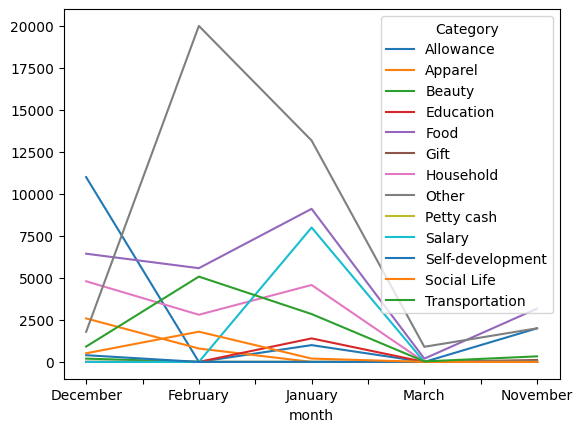

In [112]:
temp.plot()

In [114]:
temp_df = df.pivot_table(index='month',columns=['Income/Expense'],values='INR',aggfunc='sum',fill_value=0)
temp_df

Income/Expense,Expense,Income
month,,
December,16334.44,12310.0
February,17864.65,18200.0
January,20679.51,19641.0
March,525.00,600.0
November,3620.40,4003.0


<Axes: xlabel='month'>

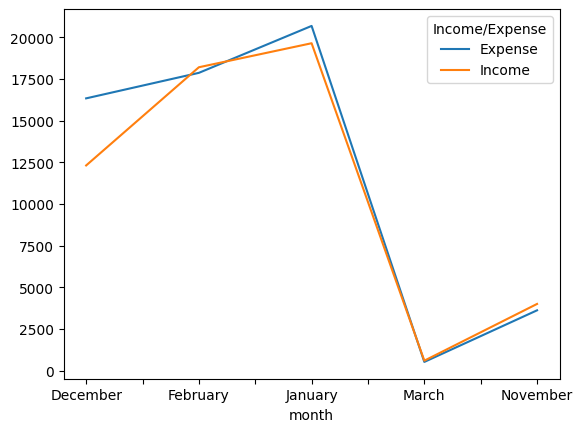

In [116]:
temp_df.plot()

<Axes: xlabel='month'>

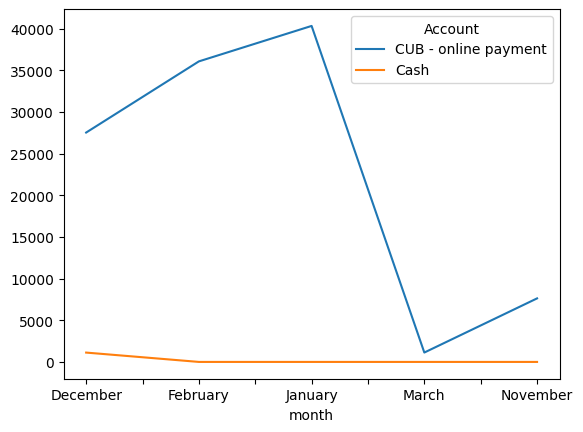

In [118]:
df.pivot_table(index='month',columns=['Account'],values='INR',aggfunc='sum',fill_value=0).plot()
